# EDA et Préparation des images — PhytoScan AI

Exploration, nettoyage et préparation du dataset **Plant_leave_diseases_dataset** pour l’entraînement du modèle de détection des maladies des plantes.

## 1. Imports et bibliothèques

 Import des bibliothèques nécessaires (manipulation fichiers, images, visualisation, split).


In [ ]:
import os
import random
import shutil
from PIL import Image
import matplotlib.pyplot as plt


## 2. Configuration des chemins

**Ce qui est fait :** Définition des dossiers principaux :
- `dataset_path` : données brutes (Plant_leave_diseases_dataset)
- `output_folder` : sortie finale splitée (plant_images)
- `balanced_dataset` : dataset équilibré intermédiaire

**Pourquoi :** Centraliser les chemins évite les erreurs et facilite les modifications de structure.

In [3]:
dataset_path = r"C:\Users\elabi\Downloads\photo_scan_ai\data\Plant_leave_diseases_dataset"  
output_folder = r"C:\Users\elabi\Downloads\photo_scan_ai\data\plant_images"  
balanced_dataset=r"C:\Users\elabi\Downloads\photo_scan_ai\data\balanced_dataset"        

## 3. Nombre de classes et noms des labels

**Ce qui est retourné :**
- **Nombre de classes :** 33
- **Liste des classes :** Noms des dossiers (ex. Apple___Apple_scab, Tomato___Late_blight…)

**Description :** Le dataset est organisé par classe (une maladie ou état par dossier). Chaque classe combine culture et pathologie (ex. Apple___Black_rot).

**Pourquoi :** Connaître le nombre et le nom des classes est indispensable pour la métrique, le one-hot encoding et l’interprétation des résultats.

In [4]:
classes = os.listdir(dataset_path)
print("Nombre de classes :", len(classes))
print(f"{classes}")

Nombre de classes : 33
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Cherry___healthy', 'Cherry___Powdery_mildew', 'Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___healthy', 'Corn___Northern_Leaf_Blight', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Strawberry___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_mosaic_virus', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus']


## 4. Distribution du nombre d’images par classe

**Ce qui est retourné :** Pour chaque classe, le nombre d’images (ex. Apple___Apple_scab : 1000, Apple___healthy : 1645, Peach___Bacterial_spot : 2297…).

**Description :** Le dataset est déséquilibré : certaines classes ont plus de 2000 images, d’autres environ 1000. Ce déséquilibre peut biaiser le modèle vers les classes majoritaires.

**Pourquoi :** Analyser la distribution permet de décider si un équilibrage (ex. 1000 images max par classe) est nécessaire pour un entraînement plus équitable.

In [5]:
counts = {}

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    counts[cls] = len(os.listdir(cls_path))

for cls, count in counts.items():
    print(f"{cls} : {count}")

Apple___Apple_scab : 1000
Apple___Black_rot : 1000
Apple___Cedar_apple_rust : 1000
Apple___healthy : 1645
Cherry___healthy : 1000
Cherry___Powdery_mildew : 1052
Corn___Cercospora_leaf_spot Gray_leaf_spot : 1000
Corn___Common_rust : 1192
Corn___healthy : 1162
Corn___Northern_Leaf_Blight : 1000
Grape___Black_rot : 1180
Grape___Esca_(Black_Measles) : 1383
Grape___healthy : 1000
Grape___Leaf_blight_(Isariopsis_Leaf_Spot) : 1076
Peach___Bacterial_spot : 2297
Peach___healthy : 1000
Pepper,_bell___Bacterial_spot : 1000
Pepper,_bell___healthy : 1478
Potato___Early_blight : 1000
Potato___healthy : 1000
Potato___Late_blight : 1000
Strawberry___healthy : 1000
Strawberry___Leaf_scorch : 1109
Tomato___Bacterial_spot : 2127
Tomato___Early_blight : 1000
Tomato___healthy : 1591
Tomato___Late_blight : 1909
Tomato___Leaf_Mold : 1000
Tomato___Septoria_leaf_spot : 1771
Tomato___Spider_mites Two-spotted_spider_mite : 1676
Tomato___Target_Spot : 1404
Tomato___Tomato_mosaic_virus : 1000
Tomato___Tomato_Yello

## 5. Visualisation de la distribution des classes

**Ce qui est retourné :** Un graphique en barres horizontales montrant le nombre d’images par classe.

**Description :** Représentation visuelle du déséquilibre entre classes (certaines bien plus peuplées que d’autres).

**Pourquoi :** Permet d’identifier rapidement les classes surreprésentées ou sous-représentées avant nettoyage et équilibrage.

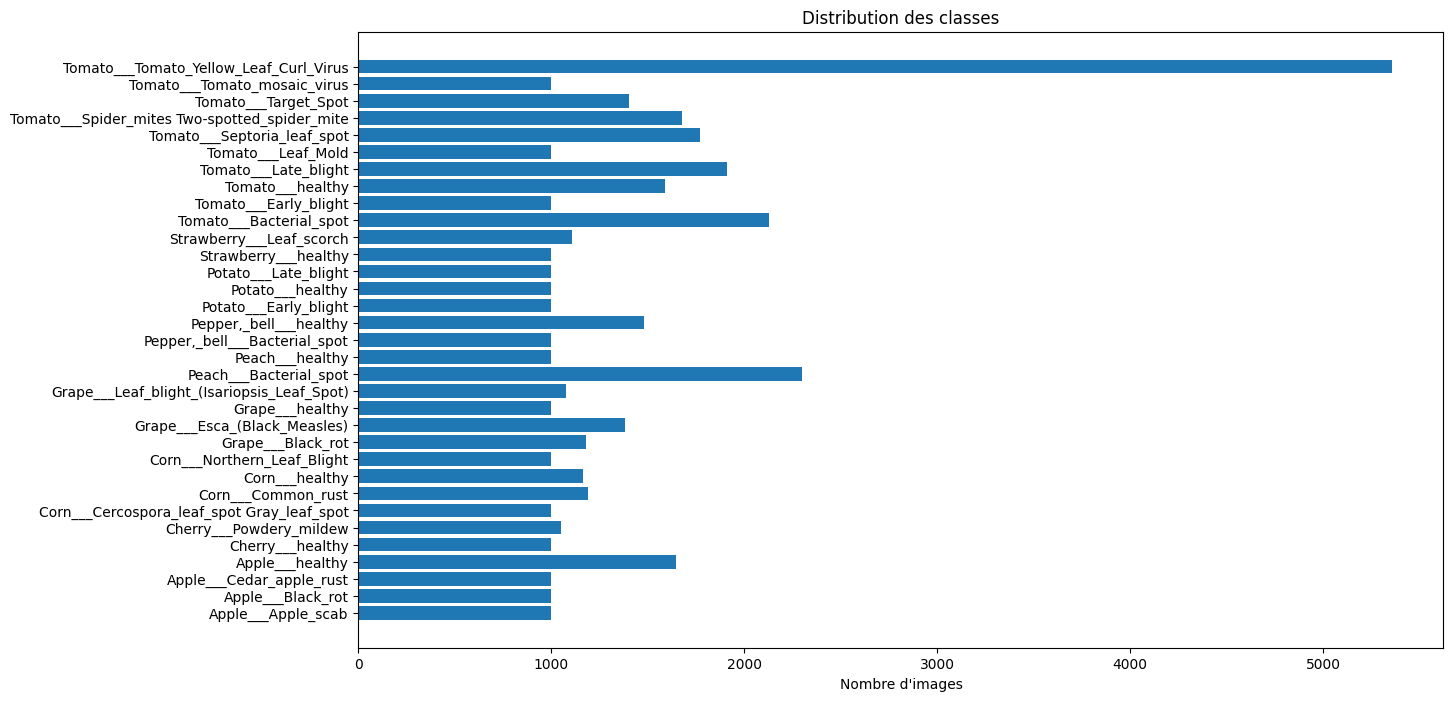

In [6]:
plt.figure(figsize=(14,8))
plt.barh(list(counts.keys()), list(counts.values()))
plt.xlabel("Nombre d'images")
plt.title("Distribution des classes")
plt.show()

## 6. Analyse des tailles des images

**Ce qui est retourné :** Les résolutions uniques trouvées, ex. `{(350, 350), (204, 204), (256, 256)}`.

**Description :** Les images n’ont pas une taille uniforme. Pour un modèle CNN, il faut une taille d’entrée fixe (ex. 256×256).

**Pourquoi :** Unifier la taille permet des batchs homogènes et des entrées compatibles avec le modèle. Le choix de 256×256 est un bon compromis qualité/calcul.

In [7]:
sizes = []

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        im = Image.open(img_path)
        sizes.append(im.size)

print(f"Tailles uniques trouvées : {set(sizes)}")

Tailles uniques trouvées : {(350, 350), (204, 204), (256, 256)}


## 7. Nettoyage des noms de classes

**Ce qui est fait :** Définition de la fonction `clean_class_name()` qui :
- passe en minuscules
- remplace `___` par `_`
- remplace espaces, virgules, parenthèses, tirets par `_`
- supprime les séquences d’underscores multiples

**Exemple :** `Apple___Cedar_apple_rust` → `apple_cedar_apple_rust`

**Pourquoi :** Des noms propres et uniformes évitent les erreurs dans les chemins, les labels et les sauvegardes de modèle.

In [8]:
import re

def clean_class_name(name):
    
    name = name.lower()
    
    name = name.replace("___", "_")
    
    name = re.sub(r"[ ,()\-]", "_", name)
    
    name = re.sub(r"_+", "_", name)
    
    return name.strip("_")

## 8. Redimensionnement et conversion RGB

**Ce qui est fait :** Création du dossier `resized_dataset` avec, pour chaque image :
- conversion en RGB
- redimensionnement à 256×256
- sauvegarde sous des noms de classes nettoyés
- gestion des erreurs (images corrompues ignorées)

**Pourquoi :** Homogénéiser les images permet l’entraînement par batch. La conversion en RGB garantit un format standard pour les modèles pré-entraînés.

In [9]:
resize_dataset = r"C:\Users\elabi\Downloads\photo_scan_ai\data\resized_dataset"


os.makedirs(resize_dataset, exist_ok=True)

for cls in os.listdir(dataset_path):

    clean_cls = clean_class_name(cls)

    cls_path = os.path.join(dataset_path, cls)

    new_cls_path = os.path.join(resize_dataset, clean_cls)

    os.makedirs(new_cls_path, exist_ok=True)

    for img_name in os.listdir(cls_path):

        try:

            img_path = os.path.join(cls_path, img_name)

            img = Image.open(img_path).convert("RGB")

            img = img.resize((256,256))

            img.save(os.path.join(new_cls_path, img_name))

        except:

            print("Erreur :", img_name)

## 9. Équilibrage du dataset

**Ce qui est fait :** Création de `balanced_dataset` en limitant à **1000 images par classe**. Les classes avec plus de 1000 images sont sous-échantillonnées de manière aléatoire.

**Pourquoi :** Réduire le déséquilibre évite que le modèle favorise les classes majoritaires et améliore la performance sur les classes minoritaires.

In [10]:
limit = 1000

for cls in os.listdir(resize_dataset):

    cls_path = os.path.join(resize_dataset, cls)

    images = os.listdir(cls_path)

    new_cls_path = os.path.join(balanced_dataset, cls)

    os.makedirs(new_cls_path, exist_ok=True)

    if len(images) > limit:

        images = random.sample(images, limit)

    for img in images:

        src = os.path.join(cls_path, img)

        dst = os.path.join(new_cls_path, img)

        shutil.copy(src, dst)

## 10. Vérification du dataset équilibré

**Ce qui est retourné :** Le nombre d’images par classe dans `balanced_dataset`. Chaque classe doit avoir exactement **1000 images** (ex. apple_apple_scab : 1000, tomato_healthy : 1000).

**Description :** Confirmation que l’équilibrage a bien été appliqué sur toutes les classes.

**Pourquoi :** Assurer que le dataset est prêt pour un split train/val/test homogène par classe.

In [11]:
classes = os.listdir(balanced_dataset)
counts = {}

for cls in classes:
    cls_path = os.path.join(balanced_dataset, cls)
    counts[cls] = len(os.listdir(cls_path))

for cls, count in counts.items():
    print(f"{cls} : {count}")

apple_apple_scab : 1000
apple_black_rot : 1000
apple_cedar_apple_rust : 1000
apple_healthy : 1000
cherry_healthy : 1000
cherry_powdery_mildew : 1000
corn_cercospora_leaf_spot_gray_leaf_spot : 1000
corn_common_rust : 1000
corn_healthy : 1000
corn_northern_leaf_blight : 1000
grape_black_rot : 1000
grape_esca_black_measles : 1000
grape_healthy : 1000
grape_leaf_blight_isariopsis_leaf_spot : 1000
peach_bacterial_spot : 1000
peach_healthy : 1000
pepper_bell_bacterial_spot : 1000
pepper_bell_healthy : 1000
potato_early_blight : 1000
potato_healthy : 1000
potato_late_blight : 1000
strawberry_healthy : 1000
strawberry_leaf_scorch : 1000
tomato_bacterial_spot : 1000
tomato_early_blight : 1000
tomato_healthy : 1000
tomato_late_blight : 1000
tomato_leaf_mold : 1000
tomato_septoria_leaf_spot : 1000
tomato_spider_mites_two_spotted_spider_mite : 1000
tomato_target_spot : 1000
tomato_tomato_mosaic_virus : 1000
tomato_tomato_yellow_leaf_curl_virus : 1000


## 11. Split Train / Validation / Test

**Ce qui est fait :** Création de la structure finale dans `plant_images` avec :
- **Train : 70 %** des images par classe
- **Validation : 15 %**
- **Test : 15 %**

Structure finale : `plant_images/train/<classe>/`, `plant_images/val/<classe>/`, `plant_images/test/<classe>/`

**Pourquoi :** Le train sert à entraîner, la validation à ajuster les hyperparamètres et le test à mesurer les performances finales sur des données jamais vues.

In [12]:
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

for cls in os.listdir(balanced_dataset):

    cls_path = os.path.join(balanced_dataset, cls)

    images = os.listdir(cls_path)

    random.shuffle(images)

    train_end = int(len(images)*train_ratio)
    val_end = int(len(images)*(train_ratio+val_ratio))

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    for split, imgs in zip(["train","val","test"], [train_imgs,val_imgs,test_imgs]):

        split_path = os.path.join(output_folder, split, cls)

        os.makedirs(split_path, exist_ok=True)

        for img in imgs:

            src = os.path.join(cls_path,img)
            dst = os.path.join(split_path,img)

            shutil.copy(src,dst)